# Temporal point processes for TESS stellar flares

This notebook compiles the branch's analysis end to end: turning a raw TESS
flare catalog and a raw TESS observation-schedule table into a properly
censored point-process dataset, then fitting and checking two candidate
models of *when* stars flare — a homogeneous Poisson process and a Hawkes
(self-exciting) process — and laying out why a neural temporal point process
(TPP) is the natural next step.

It reuses the actual project code in `scripts/` (not a re-implementation) —
each stage below imports the real functions from the corresponding script,
so this notebook and a fresh run of the scripts always agree. The narrative
cells explain *why* each step exists, aimed at someone who knows what a
point process is but hasn't necessarily fit one to messy, gappy astronomical
data before.

**Roadmap**
1. The data: a flare catalog and a spacecraft observation schedule
2. Converting the observation schedule to the flare catalog's time system (BTJD)
3. Building per-star observation windows (censoring the analysis correctly)
4. Waiting times measured on the *exposure clock*, not the calendar
5. Baseline model: homogeneous Poisson, and why it fails
6. A Hawkes process: letting flares excite future flares
7. Where this leaves us, and why a neural TPP is the natural next step

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../scripts'))

import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize
from astropy.time import Time
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline
pd.set_option("display.max_columns", 20)
np.random.seed(0)

## 1. The data

Two raw inputs live in `data/`:

- **`tess_flares_feinstein.csv`** — a preliminary catalog of stellar flares
  detected in TESS light curves: which star (`TIC`), when each flare peaked
  (`T_peak`, in BTJD — TESS's own time system, defined below), its
  amplitude, duration, and whether it's a `primary` or `secondary` event.
- **`tess_ffi_observation_times.csv`** — MIT's operations table of TESS Full
  Frame Image sector/orbit data-collection windows, as UTC calendar
  timestamps: when the spacecraft was actually collecting data at all.

A flare catalog alone tells you *when flares happened*. It says nothing
about when the telescope **wasn't looking** — and for a temporal point
process, that second piece of information is just as important as the first.

In [2]:
flares_raw = pd.read_csv("../data/tess_flares_feinstein.csv")
obs_raw = pd.read_csv("../data/tess_ffi_observation_times.csv", comment="#").dropna(how="all")

print(f"{len(flares_raw)} flares across {flares_raw['TIC'].nunique()} unique TICs")
print(f"{len(obs_raw)} sector/orbit observation windows (raw, UTC)")
flares_raw.head()

19422 flares across 2269 unique TICs
321 sector/orbit observation windows (raw, UTC)


,Unnamed: 0,TIC,T_peak,T_start,T_end,Amplitude,ED,Primary_or_Secondary,Num_Points,Num_Abv_Threshold,Amp_Sigma
0,0,84336253.0,2475.421150,2475.416983,2475.443374,0.209674,314.462516,primary,19,15,7.624682
1,1,84336253.0,2475.425317,2475.422539,2475.425317,0.210310,33.854970,primary,2,3,7.647789
2,2,84336253.0,2493.110102,2493.107324,2493.192052,3.026825,5410.659957,primary,61,57,110.068783
3,3,84336253.0,2493.115658,2493.115658,2493.118436,0.639649,115.307645,secondary,1,1,23.260478
4,4,360261300.0,1606.723513,1606.720735,1606.733235,0.057018,34.756474,primary,8,4,4.562235


### Why does a point process need observation windows at all?

A temporal point process is defined by its **intensity** λ(t) — the
instantaneous rate of events — and fitting one requires evaluating not just
"how likely was an event exactly when one happened" but also "how likely was
*no* event during the stretches when nothing happened." That second part is
the *compensator*, ∫λ(t)dt, and it has to be integrated over the time you
actually watched. TESS didn't watch continuously: sectors are broken into
~13-day orbits, separated by data-downlink gaps, and a given star is only in
the field of view for the sectors that happened to cover its patch of sky.
If a gap gets treated as "the star went quiet," the fitted intensity is
biased downward and every waiting-time distribution downstream is corrupted
by unobserved dead time posing as inactivity. Section 3 builds the true
per-star observation support from the schedule table; Section 4 uses it to
compute waiting times correctly.

## 2. Converting the observation schedule to BTJD

The flare catalog's `T_peak` is in **BTJD** (Barycentric TESS Julian Date):

$$\mathrm{BTJD} = \mathrm{BJD_{TDB}} - 2457000$$

— Barycentric Julian Date in Barycentric Dynamical Time, TESS's own
convention for keeping timestamps on one consistent clock. The observation
schedule table, by contrast, is in plain UTC calendar time. Before the two
can be compared, the schedule needs converting: UTC → TDB (leap seconds +
the 32.184 s TT−TAI offset, handled by `astropy.time.Time`) → Julian date →
BTJD.

**A caveat worth being explicit about:** this is *not* a full barycentric
light-travel-time correction. That correction depends on each target's sky
position (RA/Dec) and can shift a timestamp by up to ~8.3 minutes — but the
schedule table has no per-target coordinates to compute it from. Since
sector/orbit windows span days, that omission is immaterial for the
intended use here (assigning a flare's BTJD to the sector/orbit that covers
it). It would matter for sub-minute-precision boundary work.

In [3]:
from convert_observation_times_to_btjd import utc_to_btjd, BTJD_OFFSET

obs_raw["Start Time"] = pd.to_datetime(obs_raw["Start Time"])
obs_raw["End Time"] = pd.to_datetime(obs_raw["End Time"])

obs_btjd = obs_raw.copy()
obs_btjd["valid"] = obs_btjd["End Time"] > obs_btjd["Start Time"]
obs_btjd["Start_BTJD"] = utc_to_btjd(obs_btjd["Start Time"])
obs_btjd["End_BTJD"] = utc_to_btjd(obs_btjd["End Time"])
obs_btjd.loc[~obs_btjd["valid"], "End_BTJD"] = np.nan

# Sanity check: the UTC->TDB offset should be ~69.18s everywhere (37 leap
# seconds + the fixed 32.184s TT-TAI offset), regardless of date.
offset_days = obs_btjd["Start_BTJD"] + BTJD_OFFSET - obs_btjd["Start Time"].map(lambda t: pd.Timestamp(t).to_julian_date())
print(f"UTC->TDB offset: {offset_days.min()*86400:.3f}s to {offset_days.max()*86400:.3f}s (expected ~69.18s, constant)")

invalid = obs_btjd[~obs_btjd["valid"]]
print(f"\n{len(invalid)} row(s) with a corrupted End Time (flagged, not converted):")
invalid[["Sector", "Orbit", "Start Time", "End Time"]]

UTC->TDB offset: 69.182s to 69.186s (expected ~69.18s, constant)

1 row(s) with a corrupted End Time (flagged, not converted):


,Sector,Orbit,Start Time,End Time
68,26,60,2020-06-22 14:59:16,1971-12-31


One row — Sector 26, Orbit 60 — has a corrupted `End Time`: a
`1971-12-31` sentinel rather than a real timestamp, evidently a missing-data
placeholder in the source table. Its `Start Time` is trustworthy; its
duration is not. Rather than guessing a plausible end time, it's flagged
`valid = False` and carried through the rest of this notebook as a known,
bounded data-quality issue rather than silently patched — Sections 3–6 each
show exactly where this one row's uncertainty does and doesn't propagate.

## 3. Building per-star observation windows

Neither input table records which sectors a given star actually fell in —
the schedule table is mission-wide, not per-target. So a star's observed
sectors are **inferred** here as the sectors in which it has at least one
recorded flare. This is the best available proxy without an external
per-target sector cross-match, but it has a direction of bias worth stating
plainly: a sector where a star was observed but produced *zero* flares is
invisible to this method, so total exposure is a systematic *undercount*.

Matching each flare's `T_peak` to a window uses three tiers (implemented in
`scripts/build_observation_windows.py`, imported directly below):

- **exact** — falls inside a valid window.
- **gap_fallback** — falls inside the *invalid* Sector 26/Orbit 60 window;
  attributed there using its trustworthy start time, bounded above by the
  next window's start.
- **nearest_small_gap** — falls in a real but short (≤1 day) gap between two
  windows (e.g. an inter-orbit downlink pause); attributed to the nearer one.

Once a sector is attributed to a star, *all* of that sector's valid orbit
windows are kept as its observation support there — a target is either in a
sector's field of view for the sector's full duration or not at all.

In [4]:
from build_observation_windows import match_flares_to_windows

flares = flares_raw.copy()
flares["TIC"] = flares["TIC"].astype(int)

obs_all = obs_btjd.sort_values("Start_BTJD").reset_index(drop=True)
obs_valid = obs_all[obs_all["valid"]].reset_index(drop=True)

match = match_flares_to_windows(flares["T_peak"].to_numpy(), obs_all)
flares = pd.concat([flares, match], axis=1)

print("Flare-to-window match tiers:")
print(flares["match_type"].value_counts().to_string())

# Sectors inferred as "observed" for each TIC: any sector attributed by any tier.
attributed = flares[flares["Sector"] != -1]
observed_sectors = attributed[["TIC", "Sector"]].drop_duplicates()
windows = observed_sectors.merge(obs_valid, on="Sector", how="left")
windows = windows[["TIC", "Sector", "Orbit", "Start_BTJD", "End_BTJD"]].dropna()
windows = windows.sort_values(["TIC", "Start_BTJD"]).reset_index(drop=True)

print(f"\n{len(windows)} per-star window rows for {windows['TIC'].nunique()} TICs")
exposure_per_tic = (windows["End_BTJD"] - windows["Start_BTJD"]).groupby(windows["TIC"]).sum()
print(f"Median exposure per star: {exposure_per_tic.median():.1f} days; total: {exposure_per_tic.sum():.0f} days")

Flare-to-window match tiers:
match_type
exact                19402
gap_fallback            18
nearest_small_gap        2

14910 per-star window rows for 2269 TICs
Median exposure per star: 46.4 days; total: 132235 days


No flare is left unmatched — every one of the 19,422 recorded flares
lands in a `exact`, `gap_fallback`, or `nearest_small_gap` bucket, so no star
silently drops out of the analysis for want of a window. `windows` is now
the authoritative per-(star, sector, orbit) observation table that every
later section integrates over.

## 4. Waiting times on the *exposure clock*, not the calendar

The most tempting — and wrong — way to get flare waiting times is
`np.diff(T_peak)` per star. That silently folds months-long inter-sector
gaps into "the star went quiet," which corrupts both a fitted rate and every
downstream goodness-of-fit test.

Instead, each waiting time is measured on the **exposure clock**: the
`windows` table integrated between two flares, so that time TESS wasn't
looking doesn't count as part of the wait. Concretely, for two flares at
$t_{i-1}$ and $t_i$, the exposure-time wait is the total duration of the
overlap between $[t_{i-1}, t_i]$ and the star's own observation windows —
implemented as `exposure_between` in `scripts/compute_exposure_waiting_times.py`.

Three interval types are built per star: `initial` (window start → first
flare), `interevent` (flare → flare, the main quantity), and
`final_censored` (last flare → window end — no event followed, but exposure
continued, which matters for an unbiased rate estimate even though it has no
associated waiting time to test).

In [5]:
from compute_exposure_waiting_times import exposure_between, corrupted_orbit_ranges, overlaps_any

corrupted_ranges = corrupted_orbit_ranges(obs_all)

rows = []
for tic, wgrp in windows.groupby("TIC"):
    win_starts = wgrp["Start_BTJD"].to_numpy()
    win_ends = wgrp["End_BTJD"].to_numpy()
    obs_start, obs_end = win_starts.min(), win_ends.max()

    fgrp = flares[flares["TIC"] == tic].sort_values("T_peak")
    peaks = fgrp["T_peak"].to_numpy()
    match_types = fgrp["match_type"].to_numpy()

    boundaries = np.concatenate([[obs_start], peaks, [obs_end]])
    n = len(peaks)
    labels = (["initial"] if n >= 1 else []) + ["interevent"] * max(n - 1, 0) + (["final_censored"] if n >= 1 else [])

    for i in range(len(boundaries) - 1):
        t0, t1 = boundaries[i], boundaries[i + 1]
        exp = exposure_between(t0, t1, win_starts, win_ends)
        cal = t1 - t0
        rows.append({
            "TIC": tic, "waiting_time_type": labels[i],
            "t_prev_btjd": t0, "t_curr_btjd": t1,
            "exposure_days": exp, "calendar_days": cal,
            "unobserved_days": cal - exp,
            "overlaps_corrupted_orbit": overlaps_any(t0, t1, corrupted_ranges),
            "match_type_curr": match_types[i] if i < n else np.nan,
        })

wait = pd.DataFrame(rows)
interevent = wait[wait["waiting_time_type"] == "interevent"]
clean = interevent[~interevent["overlaps_corrupted_orbit"]]
print(f"{len(wait)} waiting-time rows; {len(interevent)} interevent, {len(clean)} of those unaffected by the corrupted orbit")
print(f"Pooled interevent exposure_days: mean={clean['exposure_days'].mean():.3f}d, "
      f"CV={clean['exposure_days'].std()/clean['exposure_days'].mean():.3f}  "
      f"(CV=1 would be Poisson-consistent; >1 suggests clustering)")

21691 waiting-time rows; 17153 interevent, 16616 of those unaffected by the corrupted orbit
Pooled interevent exposure_days: mean=5.169d, CV=1.308  (CV=1 would be Poisson-consistent; >1 suggests clustering)


**A worked example**, star TIC 230134468 (used throughout this
notebook for concreteness — it has flares that fall directly inside the
corrupted Sector 26/Orbit 60 window, which makes the bookkeeping visible):

In [6]:
EXAMPLE_TIC = 230134468
example = wait[wait["TIC"] == EXAMPLE_TIC].reset_index(drop=True)
example[["waiting_time_type", "t_prev_btjd", "t_curr_btjd", "exposure_days", "calendar_days", "overlaps_corrupted_orbit"]].iloc[30:39]

,waiting_time_type,t_prev_btjd,t_curr_btjd,exposure_days,calendar_days,overlaps_corrupted_orbit
30,interevent,1973.103820,1977.216264,4.112444,4.112444,False
31,interevent,1977.216264,1991.181355,12.590091,13.965091,False
32,interevent,1991.181355,2008.982527,16.509506,17.801172,False
33,interevent,2008.982527,2015.832446,5.870752,6.849919,False
34,interevent,2015.832446,2018.469919,2.637473,2.637473,False
35,interevent,2018.469919,2023.574037,3.717872,5.104118,True
36,interevent,2023.574037,2023.628203,0.000000,0.054166,True
37,interevent,2023.628203,2030.233697,0.000000,6.605494,True
38,interevent,2030.233697,2590.394481,10.595821,560.160784,True


Rows 33–34 show `exposure_days = 0` for intervals that lie entirely
inside the corrupted, unknown-duration window — correctly treated as *no
measurable exposure*, not silently assigned some guessed duration — and
they're flagged `overlaps_corrupted_orbit = True` so they can be (and, from
here on, are) excluded from anything sensitive to that distinction. A CV
around 1.3 above is the first hint the data isn't quietly Poisson; Section 5
tests that formally.

## 5. Baseline model: homogeneous Poisson, and why it fails

The simplest possible model of "when do flares happen" is a constant rate:

$$\lambda(t) = \mu$$

no memory, no clustering — every instant is equally likely to produce a
flare. It's fit by maximum likelihood: $\hat\mu = N / E$, events over total
exposure.

### The idea behind the goodness-of-fit test: a "stretched clock"

To check whether this constant-rate story is *right*, rather than just
plausible, use the **time-rescaling theorem**. Picture converting real time
into "risk time": every stretch of calendar time is stretched or squeezed by
however much risk the model assigns to it right then. Define

$$z_i = \int_{t_{i-1}}^{t_i} \lambda(u)\, du$$

— for a constant rate, simply $\mu \times$ exposure_days. If the model's
risk assessment is exactly right, then on this rescaled clock flares should
look like the most boring possible process: one event roughly every "1 unit
of risk," so **$z_i$ should be i.i.d. Exp(1)**. Deviations from that are a
precise, checkable signature of exactly how the model is wrong — not just
whether.

In [7]:
from fit_homogeneous_poisson import fit_mu, qq_theoretical_quantiles

wait["row_in_tic"] = wait.groupby("TIC").cumcount()
clean_all = wait[~wait["overlaps_corrupted_orbit"]].copy()
closing = clean_all[clean_all["waiting_time_type"].isin(["initial", "interevent"])].copy()

mu_global = fit_mu(closing, clean_all)
closing["z_global"] = mu_global * closing["exposure_days"]
z_global = closing["z_global"].to_numpy()
ks_global = stats.kstest(z_global, "expon")

print(f"mu_hat = {mu_global:.5f} flares/day  (mean wait 1/mu = {1/mu_global:.3f} d)")
print(f"mean(z), var(z) = {z_global.mean():.4f}, {z_global.var():.4f}  (Exp(1): both = 1)")
print(f"KS test vs Exp(1): D = {ks_global.statistic:.4f}, p = {ks_global.pvalue:.3e}")
print(f"-> {'REJECTED' if ks_global.pvalue < 0.05 else 'not rejected'} at alpha=0.05")

mu_hat = 0.14962 flares/day  (mean wait 1/mu = 6.684 d)
mean(z), var(z) = 0.8403, 1.0485  (Exp(1): both = 1)
KS test vs Exp(1): D = 0.1384, p = 3.995e-316
-> REJECTED at alpha=0.05


In [8]:
# Counterexample: what happens if you skip the exposure correction and
# just use np.diff(T_peak)-style calendar gaps? (This is the mistake
# Section 4 was built specifically to avoid.)
E_calendar = clean_all["calendar_days"].sum()
mu_naive = len(closing) / E_calendar
z_naive = mu_naive * closing["calendar_days"].to_numpy()
ks_naive = stats.kstest(z_naive, "expon")
print(f"Naive calendar-time mu_hat = {mu_naive:.5f} flares/day")
print(f"var(z) = {z_naive.var():.2f} (should be 1)  KS: D = {ks_naive.statistic:.4f}, p = {ks_naive.pvalue:.3e}")
print("-> far worse than the exposure-corrected fit above, exactly as expected")

Naive calendar-time mu_hat = 0.07135 flares/day
var(z) = 20.92 (should be 1)  KS: D = 0.3143, p = 0.000e+00
-> far worse than the exposure-corrected fit above, exactly as expected


In [9]:
# Per-star fit: mu_TIC = N_TIC / E_TIC separately per star (>=3 clean
# events), residuals pooled after fitting. This isolates whether flaring is
# non-Poisson *within* a star's own timeline from the much larger, and
# unsurprising, fact that different stars simply flare at different rates.
z_per_star_parts = []
for tic, g in clean_all.groupby("TIC"):
    g_closing = g[g["waiting_time_type"].isin(["initial", "interevent"])]
    if len(g_closing) < 3:
        continue
    mu_star = fit_mu(g_closing, g)
    z_per_star_parts.append(mu_star * g_closing["exposure_days"].to_numpy())
z_per_star = np.concatenate(z_per_star_parts)
ks_per_star = stats.kstest(z_per_star, "expon")
print(f"Stars used: {len(z_per_star_parts)}, residuals pooled: {len(z_per_star)}")
print(f"KS test vs Exp(1): D = {ks_per_star.statistic:.4f}, p = {ks_per_star.pvalue:.3e}")
print("-> rejected even after removing each star's own average rate: the non-Poisson")
print("   structure is within individual stars' timelines, not just between-star rate variation")

Stars used: 1287, residuals pooled: 17499
KS test vs Exp(1): D = 0.0520, p = 1.454e-41
-> rejected even after removing each star's own average rate: the non-Poisson
   structure is within individual stars' timelines, not just between-star rate variation


In [10]:
# Independence check: successive z_i (same star, truly adjacent) shouldn't
# be correlated if flares are really unpredictable given the model.
closing_sorted = closing.sort_values(["TIC", "row_in_tic"]).reset_index(drop=True)
prev_tic = closing_sorted["TIC"].shift(1)
prev_row = closing_sorted["row_in_tic"].shift(1)
prev_z = closing_sorted["z_global"].shift(1)
adjacent = (closing_sorted["TIC"] == prev_tic) & (closing_sorted["row_in_tic"] - prev_row == 1)
u_curr = 1 - np.exp(-closing_sorted.loc[adjacent, "z_global"].to_numpy())
u_prev = 1 - np.exp(-prev_z[adjacent].to_numpy())
lag1_corr_poisson = np.corrcoef(u_prev, u_curr)[0, 1]
print(f"Lag-1 correlation of u_i = 1-exp(-z_i): {lag1_corr_poisson:.4f} (0 expected under independence)")
print(f"n = {adjacent.sum()} adjacent same-star pairs -- highly significant despite the small magnitude")

Lag-1 correlation of u_i = 1-exp(-z_i): 0.2243 (0 expected under independence)
n = 16140 adjacent same-star pairs -- highly significant despite the small magnitude


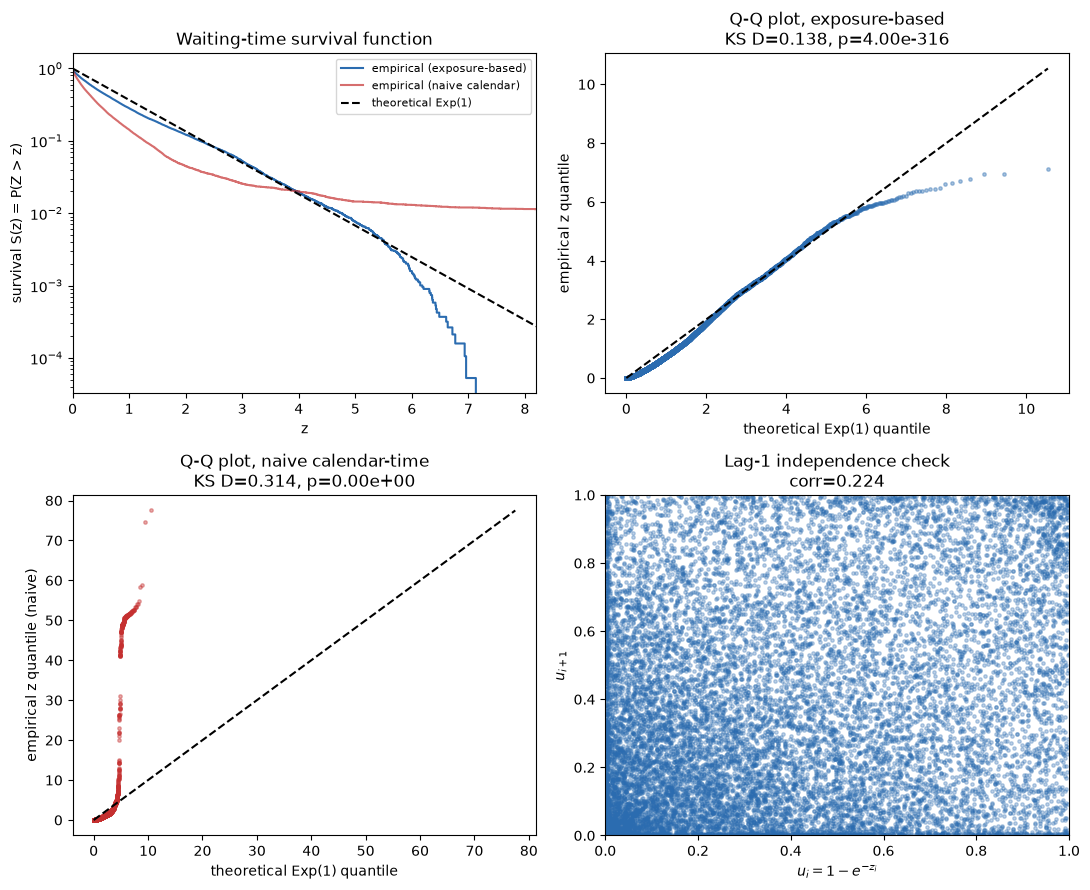

In [11]:
def survival(z):
    zs = np.sort(z)
    return zs, 1 - np.arange(1, len(zs) + 1) / len(zs)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

ax = axes[0, 0]
zs, s = survival(z_global)
ax.step(zs, s, where="post", label="empirical (exposure-based)", color="#2b6cb0")
zn, sn = survival(z_naive)
ax.step(zn, sn, where="post", label="empirical (naive calendar)", color="#c53030", alpha=0.7)
xlim = zs.max() * 1.15
zz = np.linspace(0, xlim, 200)
ax.plot(zz, np.exp(-zz), "k--", label="theoretical Exp(1)")
ax.set_yscale("log"); ax.set_xlim(0, xlim)
ax.set_xlabel("z"); ax.set_ylabel("survival S(z) = P(Z > z)")
ax.set_title("Waiting-time survival function"); ax.legend(fontsize=8)

ax = axes[0, 1]
n = len(z_global)
theo_q = qq_theoretical_quantiles(n)
ax.scatter(theo_q, np.sort(z_global), s=6, alpha=0.4, color="#2b6cb0")
lim = max(theo_q.max(), z_global.max())
ax.plot([0, lim], [0, lim], "k--")
ax.set_xlabel("theoretical Exp(1) quantile"); ax.set_ylabel("empirical z quantile")
ax.set_title(f"Q-Q plot, exposure-based\nKS D={ks_global.statistic:.3f}, p={ks_global.pvalue:.2e}")

ax = axes[1, 0]
n = len(z_naive)
theo_q = qq_theoretical_quantiles(n)
ax.scatter(theo_q, np.sort(z_naive), s=6, alpha=0.4, color="#c53030")
lim = max(theo_q.max(), z_naive.max())
ax.plot([0, lim], [0, lim], "k--")
ax.set_xlabel("theoretical Exp(1) quantile"); ax.set_ylabel("empirical z quantile (naive)")
ax.set_title(f"Q-Q plot, naive calendar-time\nKS D={ks_naive.statistic:.3f}, p={ks_naive.pvalue:.2e}")

ax = axes[1, 1]
ax.scatter(u_prev, u_curr, s=6, alpha=0.3, color="#2b6cb0")
ax.set_xlabel(r"$u_i = 1-e^{-z_i}$"); ax.set_ylabel(r"$u_{i+1}$")
ax.set_title(f"Lag-1 independence check\ncorr={lag1_corr_poisson:.3f}")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig.tight_layout()
display(fig)
plt.close(fig)

### Reading these four panels

- **Top-left (survival function):** on a log y-axis, a true Exp(1) is a
  straight diagonal line — any curvature is a visible departure. The blue
  (exposure-based) curve sags *below* the theoretical line through the
  low-to-mid range: fewer flares waited that long than a constant rate would
  predict, i.e. excess *short* waits — the visual signature of clustering.
  The red (naive calendar) curve is far worse, sitting *above* the line —
  excess *long* waits, exactly what unremoved sector gaps look like.
- **Top-right / bottom-left (Q-Q plots):** points on the diagonal mean
  agreement with Exp(1) at that quantile. The exposure-based plot tracks the
  diagonal well through the bulk of the data and bends away only in the
  tail; the naive plot departs almost immediately and curves steeply — a
  small number of enormous "waits" (really unremoved gaps) dominate it.
- **Bottom-right (independence):** points should fill the unit square
  uniformly if consecutive residuals are independent. The correlation is
  small in absolute terms (+0.22) but, with over 16,000 pairs, it is not
  noise — short waits measurably tend to follow short waits.

**Verdict: the homogeneous Poisson process is decisively rejected**, both
globally and per-star (so this isn't just "different stars have different
rates"). The pattern — excess short waits, positive serial correlation —
points at self-exciting/clustered flaring. Section 6 tests that directly.

## 6. A Hawkes process: letting flares excite future flares

A **kernel** answers: if a flare just happened, how much does the risk of
another flare jump up right now, and how fast does that bump fade? The
simplest, most standard choice — used here — is a single **exponential
kernel**: every flare gives an instantaneous jump in risk that then decays
away at a constant rate, like a plucked string settling back to silence:

$$\lambda(t) = \mu + \alpha \sum_{t_j < t} e^{-\beta (t - t_j)}$$

- **μ** — the background rate (same role as the Poisson μ).
- **α** — the size of the jump each flare adds.
- **β** — how fast that jump decays; $1/\beta$ is the characteristic
  fade-out time.
- **α/β**, the *branching ratio* — the expected number of "child" flares one
  flare directly triggers, a clean single-number summary of "how self-driven
  is this system."

One shared (μ, α, β) is fit across **all** stars at once (each star's flare
sequence is treated as an independent realization of the same process — no
cross-star triggering, these are different objects). This mirrors the
Poisson section's *global* fit, not its per-star one: with a median of 3
flares per star, there isn't enough history in most individual stars to fit
3 parameters reliably, so a per-star Hawkes kernel is flagged as a natural
refinement rather than attempted here.

### Fitting: the two pieces of the likelihood

Same principle as the Poisson fit, richer formula. For one star's sequence:

1. **Reward** for correctly predicting where flares landed: at each flare,
   evaluate $\log\lambda(t)$ using only *earlier* flares, and sum.
2. **Penalty** for total risk "spent": subtract $\int\lambda(t)\,dt$ over the
   time the star was actually watched — the **compensator**. Without this
   piece, the optimizer would just crank $\lambda(t)$ up everywhere.

**This is exactly where the TESS windows come back in** — but only for
piece 2. The compensator integrates window by window, using the real
per-star `windows` table from Section 3, so gaps (a star out of view for
months) contribute nothing. The excitation sum in piece 1, by contrast, uses
*every* recorded flare's real timestamp regardless of which window it fell
in or how confidently it was matched — a flare's own time is known
precisely even in stretches where the surrounding window isn't trusted.

In [12]:
import fit_hawkes_process as hawkes_mod
from fit_hawkes_process import excitation_integral, compensator, event_log_intensities, neg_log_likelihood

# load_star_data() reads its two input CSVs from disk using paths relative
# to the repo root (as the script is normally run); point it at the right
# place since this notebook's working directory is notebooks/.
hawkes_mod.FLARES_PATH = "../data/tess_flares_feinstein_tagged.csv"
hawkes_mod.WINDOWS_PATH = "../data/tess_per_star_observation_windows.csv"
events, wins = hawkes_mod.load_star_data()
n_total_events = sum(len(v) for v in events.values())
print(f"{n_total_events} flares across {len(events)} TICs, {sum(len(v) for v in wins.values())} windows loaded for the fit")

19422 flares across 2269 TICs, 14910 windows loaded for the fit


In [13]:
# Sanity check: at alpha->0 the Hawkes likelihood should exactly reproduce
# the pure-Poisson likelihood at the same mu (computed two independent ways).
mu_check = 0.15
E_total = sum(b - a for w in wins.values() for a, b in w)
ll_poisson_direct = n_total_events * np.log(mu_check) - mu_check * E_total
ll_hawkes_alpha0 = -neg_log_likelihood(np.log([mu_check, 1e-12, 1.0]), events, wins)
print(f"direct Poisson log-likelihood   = {ll_poisson_direct:.3f}")
print(f"Hawkes(alpha->0) log-likelihood = {ll_hawkes_alpha0:.3f}")
print(f"difference = {abs(ll_poisson_direct - ll_hawkes_alpha0):.6f} (should be ~0 -- confirms the windows are")
print("being folded into the compensator correctly, not silently ignored)")

direct Poisson log-likelihood   = -56681.099
Hawkes(alpha->0) log-likelihood = -56681.099
difference = 0.000000 (should be ~0 -- confirms the windows are
being folded into the compensator correctly, not silently ignored)


In [14]:
x0 = np.log([0.08, 0.3, 1.0])
res = minimize(neg_log_likelihood, x0, args=(events, wins), method="L-BFGS-B")
mu_hat, alpha_hat, beta_hat = np.exp(res.x)
branching_ratio = alpha_hat / beta_hat

ll_hawkes = -res.fun
lr_stat = 2 * (ll_hawkes - ll_poisson_direct)
lr_pvalue = stats.chi2.sf(lr_stat, df=2)
aic_poisson = -2 * ll_poisson_direct + 2 * 1
aic_hawkes = -2 * ll_hawkes + 2 * 3

print(f"Converged: {res.success}, {res.nit} iterations")
print(f"mu_hat    = {mu_hat:.5f} flares/day (background rate)")
print(f"alpha_hat = {alpha_hat:.5f} flares/day (excitation jump size)")
print(f"beta_hat  = {beta_hat:.5f} /day  (decay timescale 1/beta = {1/beta_hat:.2f} d)")
print(f"branching ratio alpha/beta = {branching_ratio:.4f}  "
      f"({'stationary' if branching_ratio < 1 else 'NON-STATIONARY'})")
print(f"\nLikelihood-ratio test vs Poisson (2 extra params): stat = {lr_stat:.2f}, p = {lr_pvalue:.3e}")
print(f"AIC: Poisson = {aic_poisson:.1f}, Hawkes = {aic_hawkes:.1f}  (delta = {aic_hawkes - aic_poisson:.1f})")

Converged: True, 14 iterations
mu_hat    = 0.08295 flares/day (background rate)
alpha_hat = 0.05078 flares/day (excitation jump size)
beta_hat  = 0.08030 /day  (decay timescale 1/beta = 12.45 d)
branching ratio alpha/beta = 0.6324  (stationary)

Likelihood-ratio test vs Poisson (2 extra params): stat = 4790.88, p = 0.000e+00
AIC: Poisson = 113364.2, Hawkes = 108577.3  (delta = -4786.9)


**In plain terms:** a star has some steady baseline flare rate, and
every flare it produces adds a temporary spike to that rate which then fades
over roughly a week and a half. The branching ratio says that, out of every
100 flares, roughly 63 more exist *because* those 100 happened. The
likelihood-ratio test and ΔAIC above are about as one-sided as a model
comparison gets — self-excitation is real and strongly preferred over a
constant rate, for just 2 extra parameters.

### Making the windows/excitation split concrete: TIC 230134468 again

Recall this star has flares landing directly inside the corrupted Sector
26/Orbit 60 window. Two of them, at BTJD 2023.574037 and 2023.628203, are
only 0.054 days (~78 minutes) apart. This makes the asymmetry between the
two likelihood pieces visible with real numbers, using the fit above.

In [15]:
t_target = 2023.628203
ev_tic = events[EXAMPLE_TIC]
hist = ev_tic[ev_tic < t_target]

contribs = alpha_hat * np.exp(-beta_hat * (t_target - hist))
lam_val = mu_hat + contribs.sum()
print(f"lambda(t={t_target}) just before this flare = mu + excitation = "
      f"{mu_hat:.5f} + {contribs.sum():.5f} = {lam_val:.5f} flares/day")

order = np.argsort(-contribs)
print("\nTop contributors to that excitation sum (piece 1 -- uses every flare's real time):")
for i in order[:4]:
    print(f"  t_j={hist[i]:.6f}  dt={t_target-hist[i]:8.4f} d  contribution={contribs[i]:.5f}")

a, b = 2023.574037, 2023.628203
win_list = wins.get(EXAMPLE_TIC, [])
covered = any(ws <= a and we >= b for ws, we in win_list)
exc_integral = excitation_integral(a, b, hist, alpha_hat, beta_hat)
would_be_charged = mu_hat * (b - a) + exc_integral
print(f"\nIs [{a}, {b}] inside a *trusted* window? {covered}")
print(f"Compensator integral over this stretch, if it HAD been charged (piece 2): {would_be_charged:.6f}")
print("This amount is never subtracted in the actual fit, since Orbit 60 isn't in `wins` --")
print("the model gets credit for predicting the second flare well, without paying the matching")
print("cost for how confidently it was predicting elevated risk throughout that same stretch.")

lambda(t=2023.628203) just before this flare = mu + excitation = 0.08295 + 0.13434 = 0.21730 flares/day

Top contributors to that excitation sum (piece 1 -- uses every flare's real time):
  t_j=2023.574037  dt=  0.0542 d  contribution=0.05056
  t_j=2018.469919  dt=  5.1583 d  contribution=0.03356
  t_j=2015.832446  dt=  7.7958 d  contribution=0.02715
  t_j=2008.982527  dt= 14.6457 d  contribution=0.01567

Is [2023.574037, 2023.628203] inside a *trusted* window? False
Compensator integral over this stretch, if it HAD been charged (piece 2): 0.011786
This amount is never subtracted in the actual fit, since Orbit 60 isn't in `wins` --
the model gets credit for predicting the second flare well, without paying the matching
cost for how confidently it was predicting elevated risk throughout that same stretch.


This is a small, bounded, and now precisely quantified asymmetry —
concentrated in the ~18 flares (~11 stars) touching this one corrupted
window, not spread invisibly through the dataset. It's the deliberate,
honest trade-off against either fabricating Orbit 60's true duration or
discarding three real, measured flares outright.

### Residual diagnostics for the Hawkes fit — the same test, sharper tool

`z_i` is computed exactly as before, but now integrating the *fitted
self-exciting* intensity instead of a constant one, over the observed
sub-segments of each `initial`/`interevent` interval.

In [16]:
z_hawkes = np.empty(len(closing))
for idx, row in enumerate(closing.itertuples()):
    tic = row.TIC
    t_prev, t_curr = row.t_prev_btjd, row.t_curr_btjd
    hist = events[tic][events[tic] <= t_prev]
    z = 0.0
    for a, b in wins.get(tic, []):
        lo, hi = max(a, t_prev), min(b, t_curr)
        if hi > lo:
            z += mu_hat * (hi - lo) + excitation_integral(lo, hi, hist, alpha_hat, beta_hat)
    z_hawkes[idx] = z
closing["z_hawkes"] = z_hawkes

ks_hawkes = stats.kstest(z_hawkes, "expon")
print(f"mean(z), var(z) = {z_hawkes.mean():.4f}, {z_hawkes.var():.4f}  (Exp(1): both = 1)")
print(f"KS test vs Exp(1): D = {ks_hawkes.statistic:.4f}, p = {ks_hawkes.pvalue:.3e}  "
      f"(Poisson baseline: D = {ks_global.statistic:.4f})")

closing_sorted2 = closing.sort_values(["TIC", "row_in_tic"]).reset_index(drop=True)
prev_z2 = closing_sorted2["z_hawkes"].shift(1)
adjacent2 = (closing_sorted2["TIC"] == closing_sorted2["TIC"].shift(1)) & \
            (closing_sorted2["row_in_tic"] - closing_sorted2["row_in_tic"].shift(1) == 1)
u_curr2 = 1 - np.exp(-closing_sorted2.loc[adjacent2, "z_hawkes"].to_numpy())
u_prev2 = 1 - np.exp(-prev_z2[adjacent2].to_numpy())
lag1_corr_hawkes = np.corrcoef(u_prev2, u_curr2)[0, 1]
print(f"Lag-1 correlation: {lag1_corr_hawkes:.4f}  (Poisson baseline: {lag1_corr_poisson:.4f})")

mean(z), var(z) = 0.8401, 0.6890  (Exp(1): both = 1)
KS test vs Exp(1): D = 0.0641, p = 8.143e-68  (Poisson baseline: D = 0.1384)
Lag-1 correlation: 0.0274  (Poisson baseline: 0.2243)


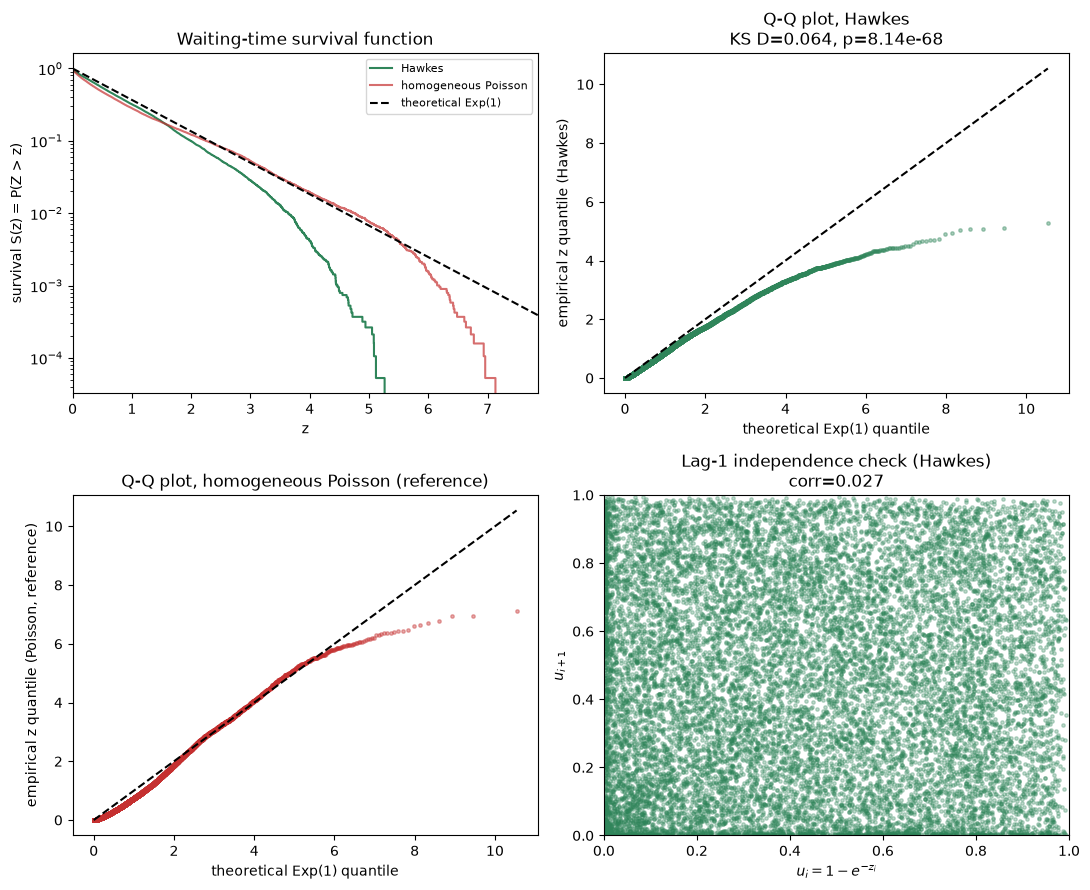

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

ax = axes[0, 0]
zs, s = survival(z_hawkes)
ax.step(zs, s, where="post", label="Hawkes", color="#2f855a")
zp, sp = survival(z_global)
ax.step(zp, sp, where="post", label="homogeneous Poisson", color="#c53030", alpha=0.7)
xlim = max(zs.max(), zp.max()) * 1.1
zz = np.linspace(0, xlim, 200)
ax.plot(zz, np.exp(-zz), "k--", label="theoretical Exp(1)")
ax.set_yscale("log"); ax.set_xlim(0, xlim)
ax.set_xlabel("z"); ax.set_ylabel("survival S(z) = P(Z > z)")
ax.set_title("Waiting-time survival function"); ax.legend(fontsize=8)

ax = axes[0, 1]
n = len(z_hawkes)
theo_q = qq_theoretical_quantiles(n)
ax.scatter(theo_q, np.sort(z_hawkes), s=6, alpha=0.4, color="#2f855a")
lim = max(theo_q.max(), z_hawkes.max())
ax.plot([0, lim], [0, lim], "k--")
ax.set_xlabel("theoretical Exp(1) quantile"); ax.set_ylabel("empirical z quantile (Hawkes)")
ax.set_title(f"Q-Q plot, Hawkes\nKS D={ks_hawkes.statistic:.3f}, p={ks_hawkes.pvalue:.2e}")

ax = axes[1, 0]
n = len(z_global)
theo_q = qq_theoretical_quantiles(n)
ax.scatter(theo_q, np.sort(z_global), s=6, alpha=0.4, color="#c53030")
lim = max(theo_q.max(), z_global.max())
ax.plot([0, lim], [0, lim], "k--")
ax.set_xlabel("theoretical Exp(1) quantile"); ax.set_ylabel("empirical z quantile (Poisson, reference)")
ax.set_title("Q-Q plot, homogeneous Poisson (reference)")

ax = axes[1, 1]
ax.scatter(u_prev2, u_curr2, s=6, alpha=0.3, color="#2f855a")
ax.set_xlabel(r"$u_i = 1-e^{-z_i}$"); ax.set_ylabel(r"$u_{i+1}$")
ax.set_title(f"Lag-1 independence check (Hawkes)\ncorr={lag1_corr_hawkes:.3f}")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig.tight_layout()
display(fig)
plt.close(fig)

### What "residual" means here, precisely

In regression, a residual is `observed - predicted`, and a good model
leaves residuals that look like structureless noise. There's no single
number to subtract in a point process, so $z_i$ plays the same role via a
"stretched clock": rescale time by how much risk the model assigns to it,
and measure the wait on that new clock. A well-calibrated model makes flares
look, on its own risk-clock, like the most boring possible process — one
event per unit of accumulated risk, i.e. $z_i \sim \mathrm{Exp}(1)$.

**Improved, but not resolved.** The Hawkes KS statistic roughly halves
(0.064 vs 0.138) and the lag-1 correlation drops by an order of magnitude
(+0.03 vs +0.22) — the kernel absorbs the great majority of the serial
dependence a constant rate completely missed. But the KS test still
formally rejects, and the *direction* of the leftover misfit has flipped:
where Poisson had too many short waits, Hawkes now has too few long ones
(the green survival curve dips *below* the red Poisson one at large z, and
its Q-Q plot bows under the diagonal). Read together with the long fitted
decay time (~12.5 days, closer to an active-region lifetime than to the
hours-scale sympathetic-flaring timescale usually invoked for direct
triggering), this points at the single shared exponential kernel being the
wrong functional form — plausibly blending two different physical
timescales into one number — and/or excitation strength genuinely varying
star to star rather than being shared globally.

## 7. Where this leaves us, and why a neural TPP is the natural next step

Two candidate models, tested the same way:

| Model | KS D | Lag-1 corr | Verdict |
|---|---|---|---|
| Homogeneous Poisson (global μ) | 0.138 | +0.224 | Rejected |
| Homogeneous Poisson (per-star μ) | 0.052 | — | Rejected (rules out "just rate heterogeneity") |
| Hawkes (shared μ, α, β) | 0.064 | +0.028 | Rejected, but a large improvement |

Self-excitation is real (the likelihood-ratio test and ΔAIC leave little
room for doubt), but a single hand-picked exponential kernel, shared across
every star, still doesn't fully capture the timing. Rather than iterating
through more hand-picked kernel shapes (a sum of two exponentials, a
power-law/Omori-type decay as used for earthquake aftershocks, ...), a
**neural temporal point process** lets the data specify the shape directly:
a small neural network learns the excitation curve — and, in principle,
how it depends on flare amplitude/energy, and how it varies star to star —
instead of us committing to one closed-form formula in advance.

Concrete reasons this dataset specifically would benefit:

- **Multiple timescales at once.** If there's a fast sympathetic-triggering
  effect *and* a slower active-region effect layered together, one
  exponential can't represent both; a neural model can.
- **Flare size is unused information.** A bigger flare plausibly triggers
  more or bigger follow-on flares — a natural "marked" point process
  extension, much easier to hand a neural network as an extra input than to
  derive a new closed-form kernel for.
- **Per-star heterogeneity without hand-splitting the model.** Both models
  above needed an explicit global-vs-per-star choice; a neural TPP can
  condition on each star's own recent history while sharing statistical
  strength across stars, rather than forcing that choice by hand.
- **The same yardstick still applies.** Whatever comes next is judged by
  exactly the diagnostic built in Sections 5–6 — does $z_i$ come out looking
  like Exp(1) — just against a more flexible intensity function.

The trade-off worth stating plainly: a neural TPP has more parameters and no
two-number summary like α/β to quote directly; its learned kernel shape is
read off by inspection (e.g. plotting the intensity it produces after a
flare) rather than a formula. Given what this notebook's diagnostics show —
genuine self-excitation, with a decay shape a single exponential doesn't
capture cleanly — that flexibility looks like the right next investment.

## Artifacts in this repo

| File | Produced by | Contents |
|---|---|---|
| `data/tess_flares_feinstein.csv` | (raw input) | Flare catalog |
| `data/tess_ffi_observation_times.csv` | (raw input) | TESS sector/orbit schedule, UTC |
| `data/tess_ffi_observation_times_btjd.csv` | `convert_observation_times_to_btjd.py` | Schedule converted to BTJD |
| `data/tess_flares_feinstein_tagged.csv` | `build_observation_windows.py` | Flares + matched Sector/Orbit/match_type |
| `data/tess_per_star_observation_windows.csv` | `build_observation_windows.py` | Per-(TIC, sector, orbit) observation windows |
| `data/tess_per_star_summary.csv` | `build_observation_windows.py` | Per-TIC flare counts, exposure, flare rate |
| `data/tess_waiting_times_exposure.csv` | `compute_exposure_waiting_times.py` | Exposure-time waiting times |
| `outputs/homogeneous_poisson_*` | `fit_homogeneous_poisson.py` | Poisson fit, GoF metrics, figure, residuals |
| `outputs/hawkes_*` | `fit_hawkes_process.py` | Hawkes fit, GoF metrics, figure, residuals |

Full provenance and caveats for each file are documented in `data/README.md`.